In [1]:
pip install py-pde 

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install h5py pandas mpi4py numba-mpi py-modelrunner napari ffmpeg-python

  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
   ---------------------------------------- 0.0/3.6 MB ? eta -:--:--
   ----------- ---------------------------- 1.0/3.6 MB 10.2 MB/s eta 0:00:01
   -------------- ------------------------- 1.3/3.6 MB 2.6 MB/s eta 0:00:01
   ----------------------- ---------------- 2.1/3.6 MB 4.1 MB/s eta 0:00:01
   ----------------------- ---------------- 2.1/3.6 MB 4.1 MB/s eta 0:00:01
   ----------------------------------- ---- 3.1/3.6 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 3.6/3.6 MB 2.9 MB/s  0:00:01
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 9.2 MB/s  0:00:00
   ---------------------------------------- 0.0/799.3 kB ? eta -:--:--
   ---------------------------------------- 799.3/799.3 kB 16.4 MB/s  0:00:00
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------------------------------- 3.2/3.2 MB 2

  0%|          | 0/200.0 [00:00<?, ?it/s]

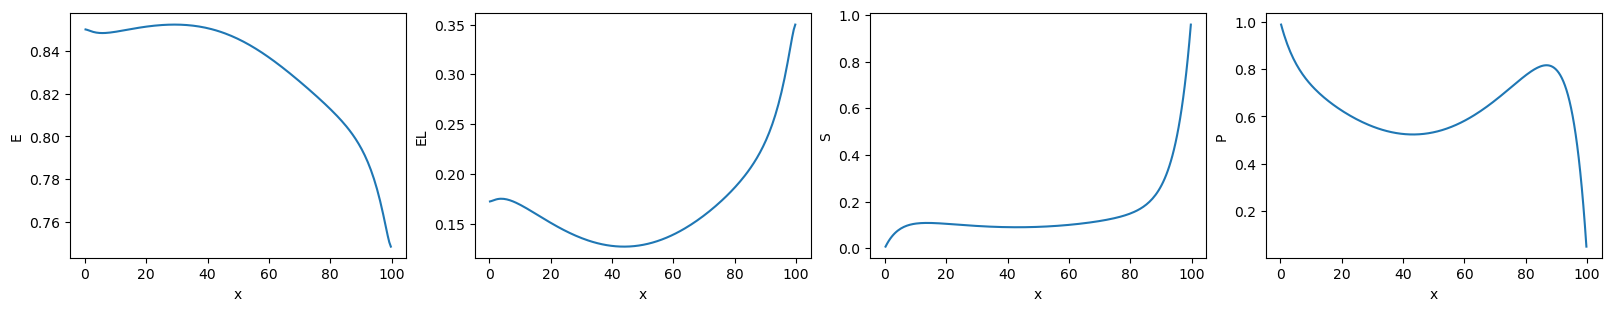

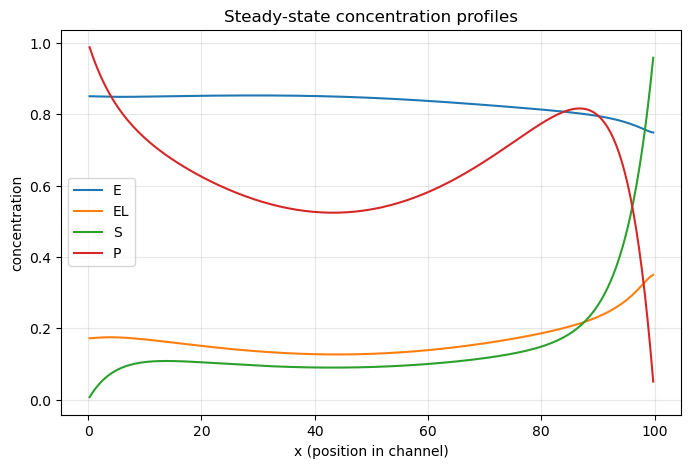

In [10]:
import pde
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1. grid ----------
L = 100.0
N = 200
grid = pde.CartesianGrid([[0, L]], [N], periodic=False)

# ---------- 2. reservoir concentration ----------
T = 1.0

# ---------- 3. the four coupled PDEs ----------
eq = pde.PDE(
    {
        "E":  "D_E*laplace(E)   - k1*E*S + km1*EL - km2*P*E + k2*EL",
        "EL": "D_EL*laplace(EL) + k1*E*S + km2*P*E - km1*EL - k2*EL",
        "S":  "D_S*laplace(S)   - k1*E*S + km1*EL",
        "P":  "D_P*laplace(P)   + k2*EL  - km2*P*E",
    },
    consts={
        "D_E": 2.0, "D_EL": 0.8, "D_S": 8.0, "D_P": 6.0,
        "k1": 0.5, "km1": 0.3, "k2": 0.7, "km2": 0.2,
    },
    bc_ops={
        "E:*":  "neumann",
        "EL:*": "neumann",
        "S:*":  ({"value": 0}, {"value": T}),
        "P:*":  ({"value": T}, {"value": 0}),
    },
)
    

# ---------- 4. initial conditions ----------
c = 1.0
E  = pde.ScalarField(grid, c,   label="E")
EL = pde.ScalarField(grid, 0.0, label="EL")
S  = pde.ScalarField(grid, 0.0, label="S")
P  = pde.ScalarField(grid, 0.0, label="P")
state = pde.FieldCollection([E, EL, S, P])

# ---------- 5. solve, saving snapshots over time ----------
storage = pde.MemoryStorage()
result = eq.solve(
    state, t_range=200, dt=1e-3,
    tracker=["progress", storage.tracker(1.0)],
)

# ---------- 6a. quick built-in plot: final profiles, all 4 fields ----------
result.plot()
plt.show()

# ---------- 6b. custom plot: overlay all 4 fields on one axis ----------
x = grid.axes_coords[0]   # the actual x positions, length 200

plt.figure(figsize=(8, 5))
plt.plot(x, result[0].data, label="E")
plt.plot(x, result[1].data, label="EL")
plt.plot(x, result[2].data, label="S")
plt.plot(x, result[3].data, label="P")
plt.xlabel("x (position in channel)")
plt.ylabel("concentration")
plt.title("Steady-state concentration profiles")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [4]:
import pde
print(pde.__version__)

0.58.0


In [7]:
import pde
import numpy as np

# ---------- 1. grid ----------
L = 100.0
N = 200
grid = pde.CartesianGrid([[0, L]], [N], periodic=False)

# ---------- 2. reservoir concentration ----------
T = 1.0   # set to your actual reservoir value

# ---------- 3. the four coupled PDEs ----------
eq = pde.PDE(
    {
        "E":  "D_E*laplace(E)   - k1*E*S + km1*EL - km2*P*E + k2*EL",
        "EL": "D_EL*laplace(EL) + k1*E*S + km2*P*E - km1*EL - k2*EL",
        "S":  "D_S*laplace(S)   - k1*E*S + km1*EL",
        "P":  "D_P*laplace(P)   + k2*EL  - km2*P*E",
    },
    consts={
        "D_E": 2.0, "D_EL": 0.8, "D_S": 8.0, "D_P": 6.0,
        "k1": 0.5, "km1": 0.3, "k2": 0.7, "km2": 0.2,
    },
    bc_ops={
        "E:*":  "neumann",
        "EL:*": "neumann",
        "S:*":  ({"value": 0}, {"value": T}),
        "P:*":  ({"value": T}, {"value": 0}),
    },
)

# ---------- 4. initial conditions ----------
c = 1.0
E  = pde.ScalarField(grid, c,   label="E")
EL = pde.ScalarField(grid, 0.0, label="EL")
S  = pde.ScalarField(grid, 0.0, label="S")
P  = pde.ScalarField(grid, 0.0, label="P")
state = pde.FieldCollection([E, EL, S, P])

# ---------- 5. solve ----------
result = eq.solve(state, t_range=200, dt=1e-3, tracker=["progress"])

# ---------- 6. print final numeric solution ----------
names = ["E", "EL", "S", "P"]
for name, field in zip(names, result):
    data = field.data
    print(f"\n{name}(x) at steady state:")
    print("  first 5 values:", np.round(data[:5], 5))
    print("  last 5 values: ", np.round(data[-5:], 5))
    print("  min / max:      ", round(data.min(), 5), "/", round(data.max(), 5))
    print("  average:        ", round(data.mean(), 5))

  0%|          | 0/200.0 [00:00<?, ?it/s]


E(x) at steady state:
  first 5 values: [0.8501  0.84991 0.84966 0.8494  0.84915]
  last 5 values:  [0.76023 0.7568  0.75345 0.75047 0.74844]
  min / max:       0.74844 / 0.85236
  average:         0.83229

EL(x) at steady state:
  first 5 values: [0.17221 0.17263 0.17319 0.17375 0.17422]
  last 5 values:  [0.32027 0.32892 0.33735 0.34483 0.34991]
  min / max:       0.12681 / 0.34991
  average:         0.16771

S(x) at steady state:
  first 5 values: [0.00699 0.01946 0.03056 0.04045 0.04925]
  last 5 values:  [0.6952  0.7516  0.81381 0.88243 0.95817]
  min / max:       0.00699 / 0.95817
  average:         0.15084

P(x) at steady state:
  first 5 values: [0.98744 0.96429 0.94295 0.92322 0.90498]
  last 5 values:  [0.3649  0.29864 0.22467 0.14228 0.05072]
  min / max:       0.05072 / 0.98744
  average:         0.64144


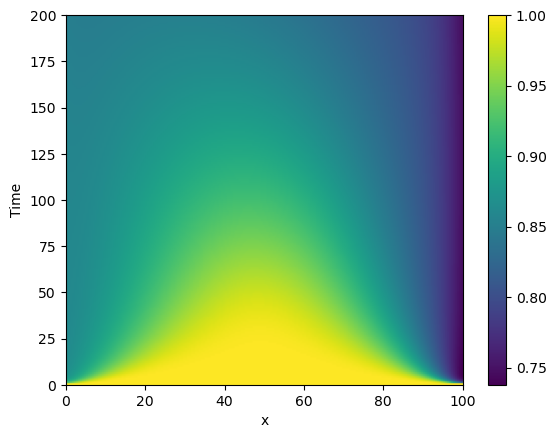

In [9]:
pde.plot_kymograph(storage , field_index =0)   # 0 = E; use storage[1]/[2]/[3] for EL/S/P
plt.show()

17/8


  0%|          | 0/200.0 [00:00<?, ?it/s]


E(x) at steady state:
  first 5 values: [0.99846 0.9984  0.99835 0.99829 0.99825]
  last 5 values:  [0.99737 0.99738 0.99738 0.99739 0.99739]
  min / max:       0.99729 / 0.99846
  average:         0.99742

EL(x) at steady state:
  first 5 values: [0.00152 0.00158 0.00163 0.00169 0.00174]
  last 5 values:  [0.00263 0.00262 0.00262 0.00261 0.00261]
  min / max:       0.00152 / 0.00271
  average:         0.00258

S(x) at steady state:
  first 5 values: [0.97524 0.92815 0.88335 0.84075 0.80022]
  last 5 values:  [0.08203 0.08567 0.08951 0.09354 0.09777]
  min / max:       0.01487 / 0.97524
  average:         0.11853

P(x) at steady state:
  first 5 values: [0.12475 0.17185 0.21663 0.25925 0.29976]
  last 5 values:  [1.01797 1.01432 1.0105  1.00646 1.00223]
  min / max:       0.12475 / 1.08509
  average:         0.98142

TOTAL ENZYME PROFILE (E + EL)

Maximum of (E + EL):
  Location: x = 12.350 μm
  Value: 1.00000e+00

Minimum of (E + EL):
  Location: x = 0.050 μm
  Value: 9.99979e-01

Di

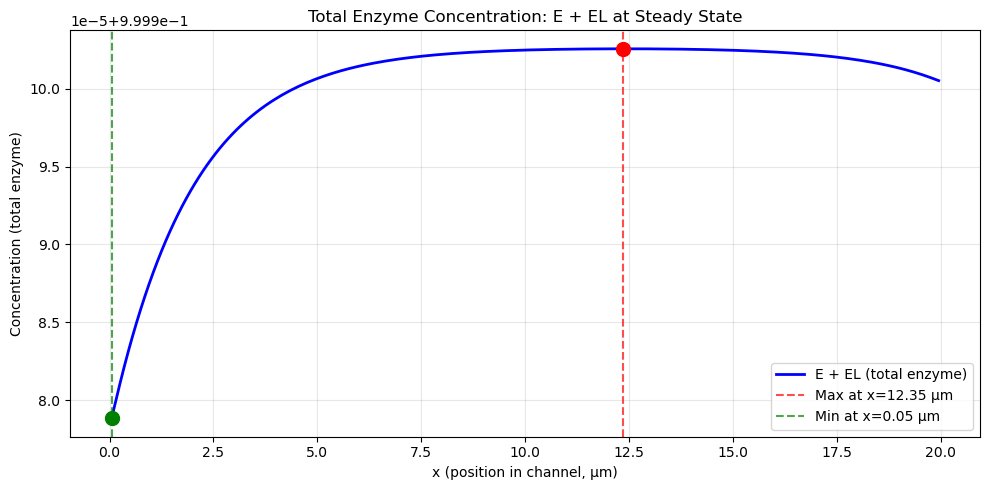

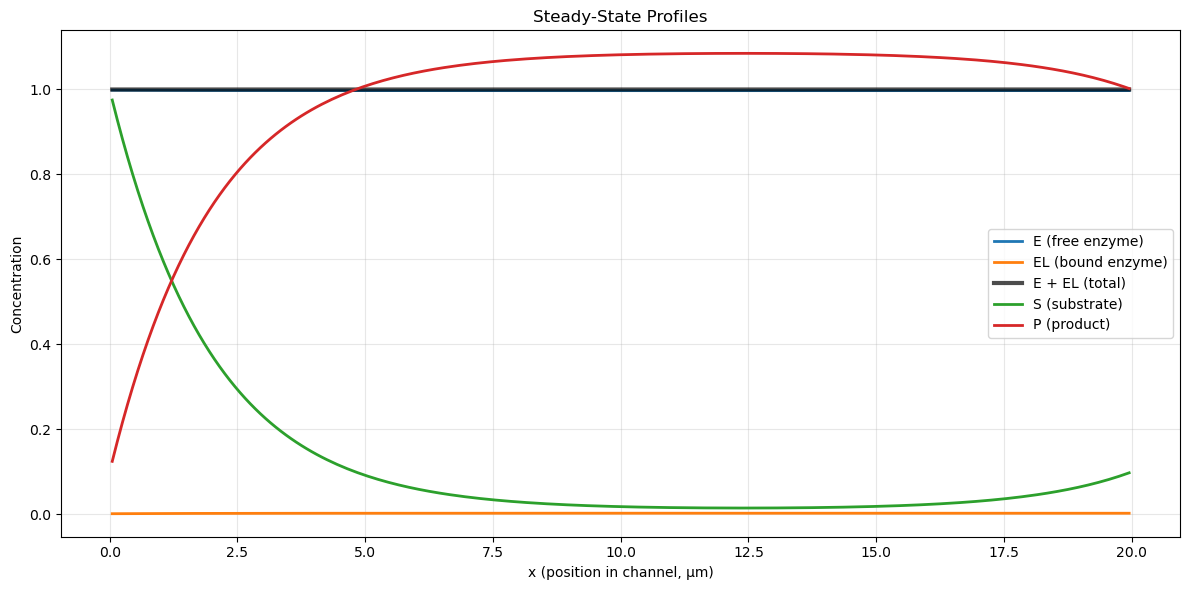

In [3]:
import pde
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1. grid ----------
L = 20.0
N = 200
grid = pde.CartesianGrid([[0, L]], [N], periodic=False)

# ---------- 2. reservoir concentration ----------
T = 1.0

# ---------- 3. parameters from your notes ----------
c = 1
D_E = 40.0
D_EL = 39.2
D_S = 400.0
D_P = 400.0
k1 = 100.0
km1 = 400.0
k2 = 80000.0
km2 = 200.0

# ---------- 4. the four coupled PDEs ----------
eq = pde.PDE(
    {
        "E":  "D_E*laplace(E)   - k1*E*S + km1*EL - km2*P*E + k2*EL",
        "EL": "D_EL*laplace(EL) + k1*E*S + km2*P*E - km1*EL - k2*EL",
        "S":  "D_S*laplace(S)   - k1*E*S + km1*EL",
        "P":  "D_P*laplace(P)   + k2*EL  - km2*P*E",
    },
    consts={
        "D_E": D_E, "D_EL": D_EL, "D_S": D_S, "D_P": D_P,
        "k1": k1, "km1": km1, "k2": k2, "km2": km2,
    },
    bc_ops={
        "E:*":  "neumann",
        "EL:*": "neumann",
        "S:*":  ({"value": T}, {"value": T/10}),
        "P:*":  ({"value": T/10}, {"value": T}),
    },
)

# ---------- 5. initial conditions ----------
E  = pde.ScalarField(grid, c,   label="E")
EL = pde.ScalarField(grid, 0.0, label="EL")
S  = pde.ScalarField(grid, 0.0, label="S")
P  = pde.ScalarField(grid, 0.0, label="P")
state = pde.FieldCollection([E, EL, S, P])

# ---------- 6. solve ----------
result = eq.solve(state, t_range=200, dt=None, tracker=["progress"])

# ---------- 7. print final numeric solution ----------
names = ["E", "EL", "S", "P"]
for name, field in zip(names, result):
    data = field.data
    print(f"\n{name}(x) at steady state:")
    print("  first 5 values:", np.round(data[:5], 5))
    print("  last 5 values: ", np.round(data[-5:], 5))
    print("  min / max:      ", round(data.min(), 5), "/", round(data.max(), 5))
    print("  average:        ", round(data.mean(), 5))

# ---------- 8. TOTAL ENZYME: E + EL, find maxima and minima ----------
x = grid.axes_coords[0]
E_data = result[0].data       # E
EL_data = result[1].data      # EL
E_total = E_data + EL_data    # Total enzyme concentration

print("\n" + "="*60)
print("TOTAL ENZYME PROFILE (E + EL)")
print("="*60)

# Find maximum
idx_max = np.argmax(E_total)
x_max = x[idx_max]
E_total_max = E_total[idx_max]

# Find minimum
idx_min = np.argmin(E_total)
x_min = x[idx_min]
E_total_min = E_total[idx_min]

print(f"\nMaximum of (E + EL):")
print(f"  Location: x = {x_max:.3f} μm")
print(f"  Value: {E_total_max:.5e}")

print(f"\nMinimum of (E + EL):")
print(f"  Location: x = {x_min:.3f} μm")
print(f"  Value: {E_total_min:.5e}")

print(f"\nDifference (max - min): {E_total_max - E_total_min:.5e}")
print(f"Relative difference: {100 * (E_total_max - E_total_min) / E_total_max:.2f}%")

# ---------- 9. PLOT total enzyme profile ----------
plt.figure(figsize=(10, 5))
plt.plot(x, E_total, 'b-', linewidth=2, label="E + EL (total enzyme)")
plt.axvline(x_max, color='r', linestyle='--', alpha=0.7, label=f"Max at x={x_max:.2f} μm")
plt.axvline(x_min, color='g', linestyle='--', alpha=0.7, label=f"Min at x={x_min:.2f} μm")
plt.scatter([x_max], [E_total_max], color='r', s=100, zorder=5)
plt.scatter([x_min], [E_total_min], color='g', s=100, zorder=5)
plt.xlabel("x (position in channel, μm)")
plt.ylabel("Concentration (total enzyme)")
plt.title("Total Enzyme Concentration: E + EL at Steady State")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- 10. OVERLAY: all fields plus total enzyme ----------
plt.figure(figsize=(12, 6))
plt.plot(x, E_data, label="E (free enzyme)", linewidth=2)
plt.plot(x, EL_data, label="EL (bound enzyme)", linewidth=2)
plt.plot(x, E_total, 'k-', label="E + EL (total)", linewidth=3, alpha=0.7)
plt.plot(x, result[2].data, label="S (substrate)", linewidth=2)
plt.plot(x, result[3].data, label="P (product)", linewidth=2)
plt.xlabel("x (position in channel, μm)")
plt.ylabel("Concentration")
plt.title("Steady-State Profiles")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()